# Inference the fine-tuned Vision Transformer Model (ViT-B-16)

The model was train to detect if the person in an image is real or AI generated

# 1. Import

In [68]:
import torch
import torch.nn.functional as F

from torchvision import models, transforms

import matplotlib.pyplot as plt
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


# 2. Connect to Google Drive

In [69]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    MODEL_PATH = '/content/drive/MyDrive/DL/FT_ViT_Fake_Real_Person.pth'
    FAKE_IMG = '/content/drive/MyDrive/DL/fake_person.png'
    REAL_IMG = '/content/drive/MyDrive/DL/zendaya.png'
except(Exception) as e:
    print("❌ Error: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 3. Transform the Input Image

In [70]:
class LetterBox:
    def __init__(self, fill_color=(128, 128, 128)):
        self.fill_color = fill_color

    def __call__(self, img):
        w, h = img.size
        side = max(w, h) # the size of the quare canvas

        # create a neutral gray square canvas
        canvas = Image.new('RGB', (side, side), self.fill_color)

        # Paste the original image centered on the canvas
        pad_left = (side - w) // 2
        pad_top = (side - h) // 2
        canvas.paste(img, (pad_left, pad_top))

        return canvas

In [71]:
stats = ((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))

IMG_SIZE = 256

inference_transform = transforms.Compose([
    LetterBox(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

# 4. Load the pretrained Weights

In [72]:
def load_weights(model_path, device):
    # 1. Load a empty model
    model = models.vit_b_16(weights=None, image_size=IMG_SIZE)
    model.heads.head = nn.Linear(model.heads.head.in_features, 2)

    # 2. Load the weights
    state_dict = torch.load(model_path, map_location=device)

    # 3. Move the weights into the model
    model.load_state_dict(state_dict)

    # 4. Set to eval mode (disables dropout, batch norm)
    model.eval()
    model.to(device)

    print("✅ Model loaded")
    return model

model = load_weights(MODEL_PATH, device);

✅ Model loaded


# 5. Predict Function

In [73]:
def predict(img_path, model, transform, classes=["fake", "real"]):
    print("Inference running ...")
    # 1. Load the Image
    img = Image.open(img_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)

    # 2. Inference
    with torch.no_grad():
        output = model(input_tensor)
        probs = F.softmax(output, dim=1)
        conf, pred = torch.max(probs, 1)

    class_name = classes[pred.item()]
    confidence = conf.item() * 100

    return class_name, confidence, img

# 6. Inference

Inference running ...
Inference running ...


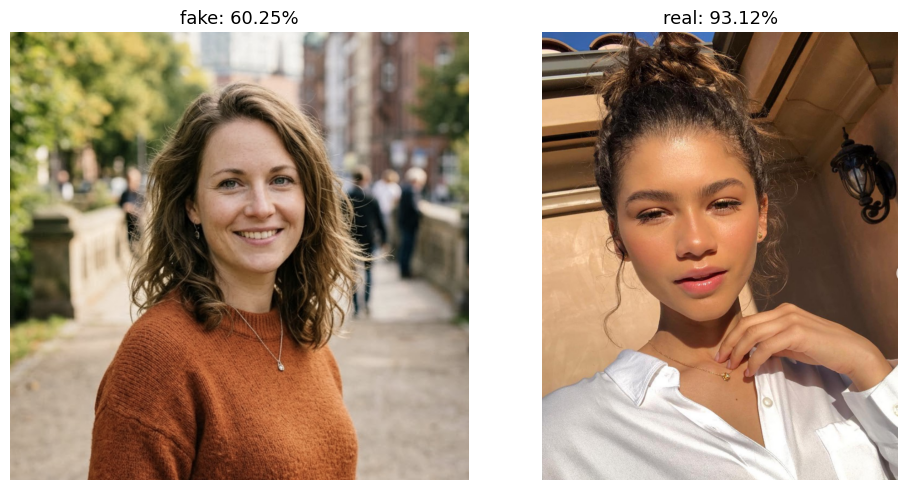

In [74]:
try:
    fake_cls, fake_score, fake_img = predict(FAKE_IMG, model, inference_transform)
    real_cls, real_score, real_img = predict(REAL_IMG, model, inference_transform)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(fake_img)
    axes[0].set_title(f"{fake_cls}: {fake_score:.2f}%", fontsize=13)
    axes[0].axis('off')

    axes[1].imshow(real_img)
    axes[1].set_title(f"{real_cls}: {real_score:.2f}%", fontsize=13)
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
except(Exception) as e:
    print(f"❌ Error: {e}")